In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
champions = pd.read_csv("world_cup.csv")
champions.head()

,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64


In [3]:
len(champions)

22

We have 22 world cup all over the history.

- Let's take a look about top scorrers and their goals.

In [4]:
top_scorer_info = champions['TopScorrer'].str.split()
num_goals = top_scorer_info.str[-1].astype(int) 

champions['num_goal_of_top_scorers'] = num_goals

In [5]:
champions['TopScorrer'] = champions['TopScorrer'].str.split(' - ').str[0]

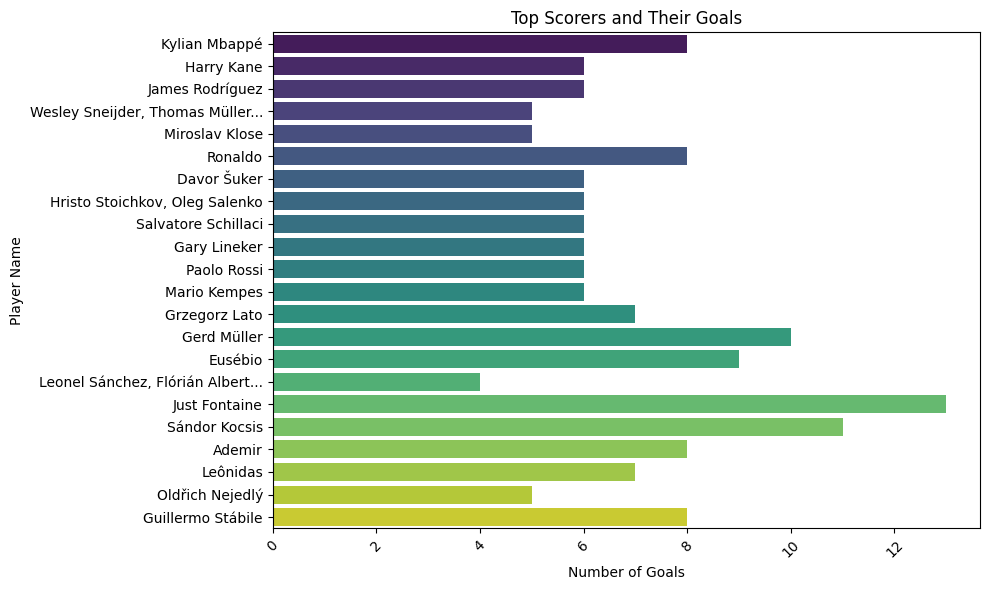

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x='num_goal_of_top_scorers', y='TopScorrer', data=champions, palette='viridis', hue='TopScorrer', dodge=False, legend=False)
plt.xlabel('Number of Goals')
plt.ylabel('Player Name')
plt.title('Top Scorers and Their Goals')
plt.xticks(rotation=45)
plt.tight_layout()

- let's show information about the player who scored the most goals in a single edition of the World Cup, he is Just Fontaine

In [7]:
champions[champions['TopScorrer'].str.contains('Just Fontaine')]

,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches,num_goal_of_top_scorers
16,1958,Sweden,16,Brazil,Sweden,Just Fontaine,819810,23423,35,13


He was runner-up in the 1958 World Cup, which was won by Brazil, and the renner-up was Sweden.

- Let's see which teams have won the most World Cups.

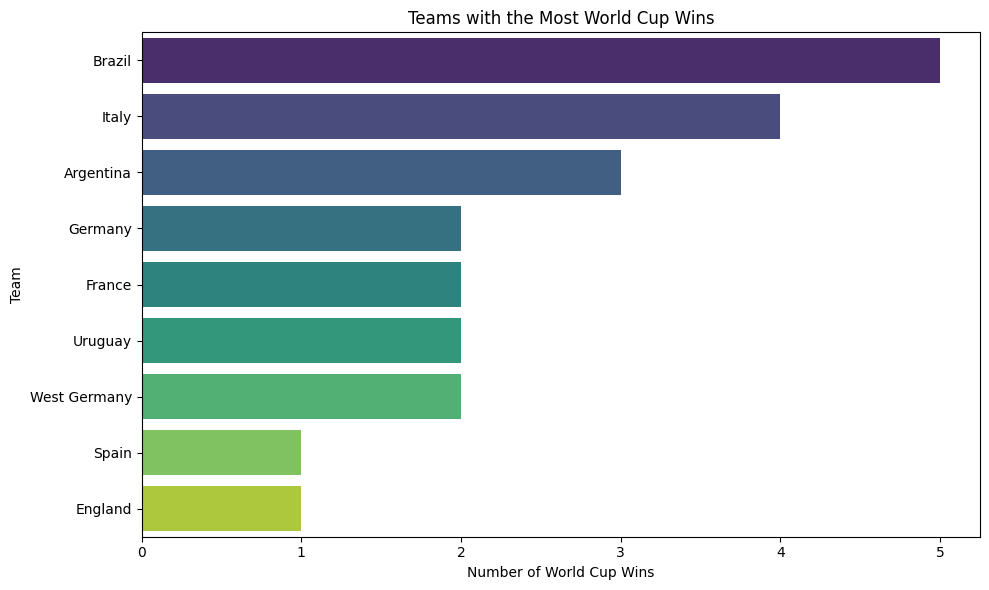

In [8]:
wins_per_team = champions['Champion'].value_counts().reset_index()
wins_per_team.columns = ['Team', 'Wins']

plt.figure(figsize=(10, 6))
sns.barplot(x='Wins', y='Team', data=wins_per_team, palette='viridis', hue='Team', dodge=False, legend=False)
plt.xlabel('Number of World Cup Wins')
plt.ylabel('Team')
plt.title('Teams with the Most World Cup Wins')
plt.tight_layout()

- Let's see which teams have finished second the most in the history of the World Cup.

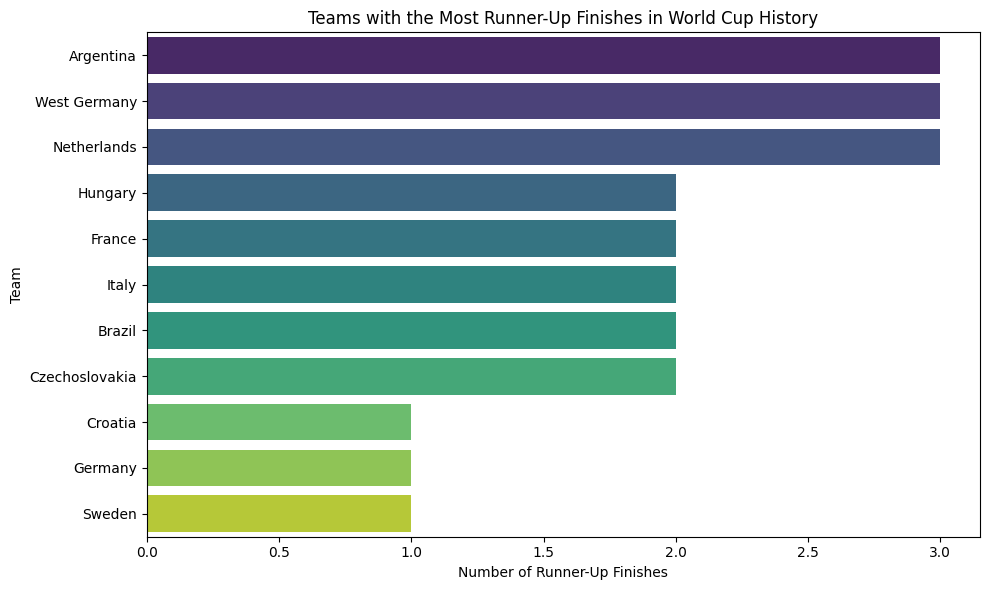

In [9]:
runner_up_counts = champions['Runner-Up'].value_counts().reset_index()
runner_up_counts.columns = ['Team', 'Runner-Up Finishes']

# Sorting by number of runner-up finishes (descending)
runner_up_counts = runner_up_counts.sort_values(by='Runner-Up Finishes', ascending=False)

# Plotting with seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Runner-Up Finishes', y='Team', data=runner_up_counts, palette='viridis', hue='Team', dodge=False, legend=False)
plt.xlabel('Number of Runner-Up Finishes')
plt.ylabel('Team')
plt.title('Teams with the Most Runner-Up Finishes in World Cup History')
plt.tight_layout()

- With these two drawings let's see which teams have reached to the World Cup final the most.

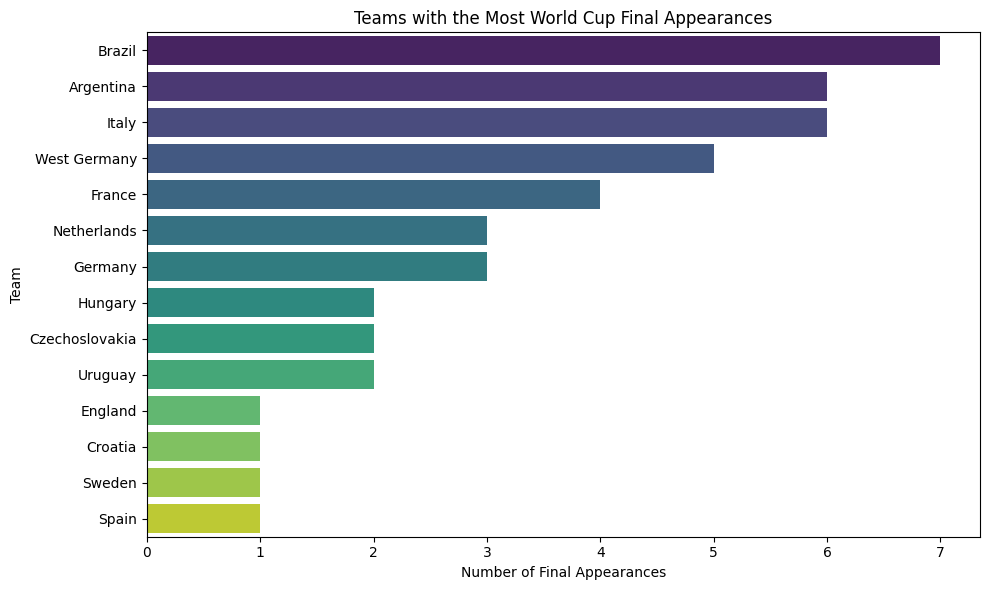

In [10]:
final_appearances_team1 = champions['Champion'].value_counts().reset_index()
final_appearances_team1.columns = ['Team', 'Final Appearances']

final_appearances_team2 = champions['Runner-Up'].value_counts().reset_index()
final_appearances_team2.columns = ['Team', 'Final Appearances']

# Combining and aggregating final appearances
final_appearances = pd.concat([final_appearances_team1, final_appearances_team2], ignore_index=True)
final_appearances = final_appearances.groupby('Team')['Final Appearances'].sum().reset_index()

# Sorting by number of final appearances (descending)
final_appearances = final_appearances.sort_values(by='Final Appearances', ascending=False)

# Plotting with seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Final Appearances', y='Team', data=final_appearances, palette='viridis', hue='Team', dodge=False, legend=False)
plt.xlabel('Number of Final Appearances')
plt.xlabel('Number of Final Appearances')
plt.ylabel('Team')
plt.title('Teams with the Most World Cup Final Appearances')
plt.tight_layout()

- Let's see the total number of views in each version of the World Cup.

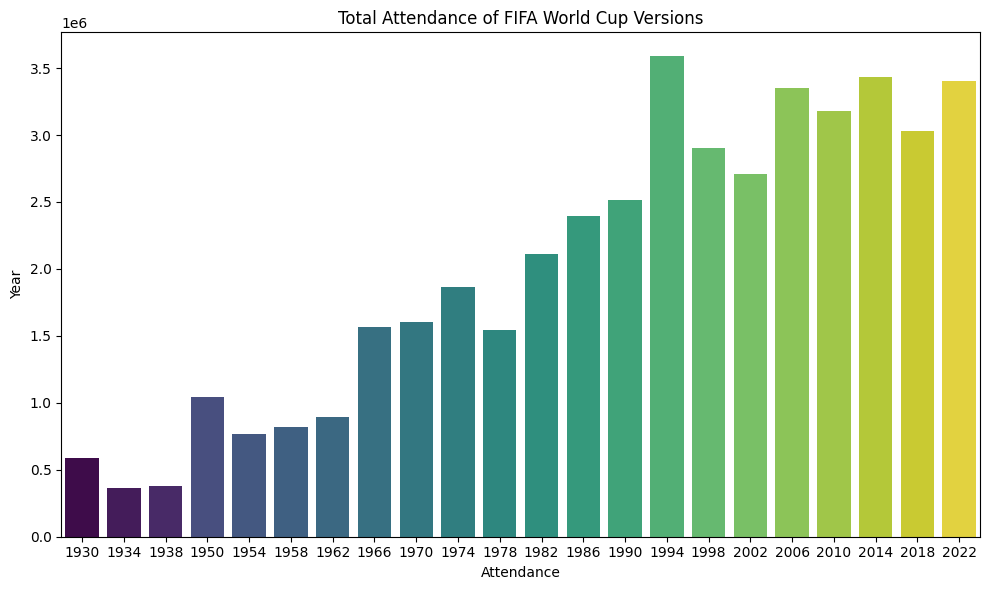

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Attendance' , data = champions, palette='viridis', hue='Year' , dodge=False , legend=False)
plt.title('Total Attendance of FIFA World Cup Versions')
plt.xlabel('Attendance')
plt.ylabel('Year')
plt.tight_layout()

- Let's see the average number of views per match in each version of the World Cup.

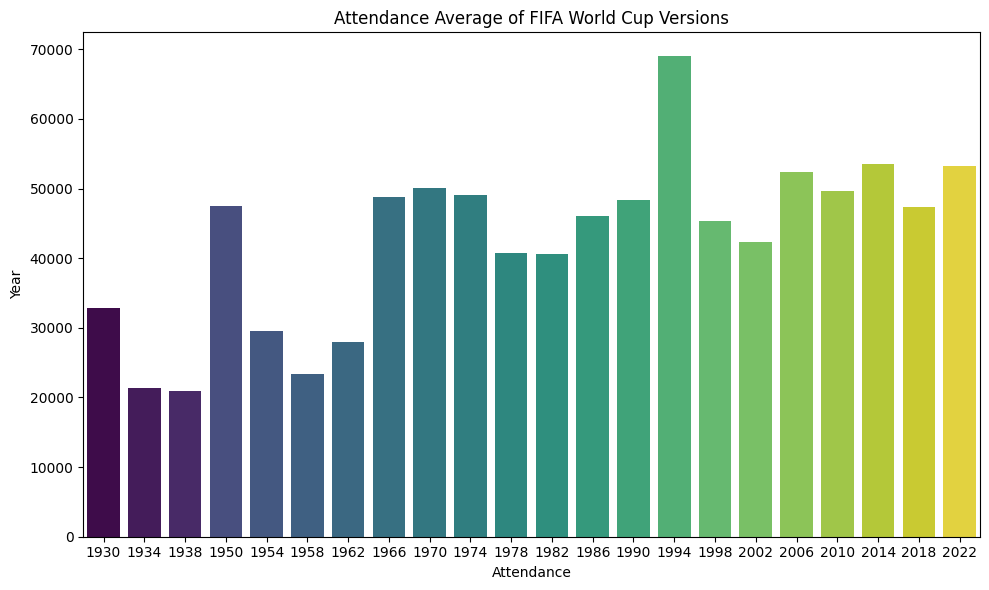

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='AttendanceAvg' , data = champions, palette='viridis', hue='Year' , dodge=False , legend=False)
plt.title('Attendance Average of FIFA World Cup Versions')
plt.xlabel('Attendance')
plt.ylabel('Year')
plt.tight_layout()

- Let's see the number of matches in each version of the World Cup.

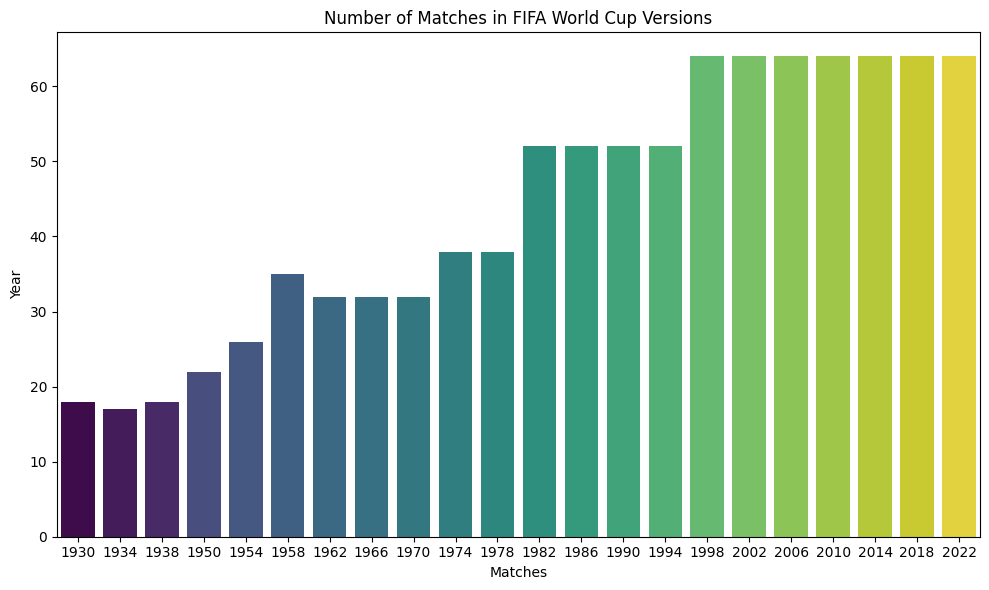

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Matches' , data = champions, palette='viridis', hue='Year' , dodge=False , legend=False)
plt.title('Number of Matches in FIFA World Cup Versions')
plt.xlabel('Matches')
plt.ylabel('Year')
plt.tight_layout()

We will notice that the 1994 World Cup edition had fewer matches than the editions from 2002 to 2022, but it was the edition with the most views.

Ours is to review the information of the 1994 version

In [14]:
champions[champions['Year'] == 1994]

,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches,num_goal_of_top_scorers
7,1994,United States,24,Brazil,Italy,"Hristo Stoichkov, Oleg Salenko",3587538,68991,52,6


We will find that the host of this version is the United States of America, so even if the number of matches in this version is less than the number of matches in the versions that followed it from 2002 to 2022, the United States of America is one of the largest countries that includes different nationalities and at the same time one of the largest countries that has a population.

- Let's see which countries have hosted the World Cup the most.

Text(0, 0.5, 'Host Country')

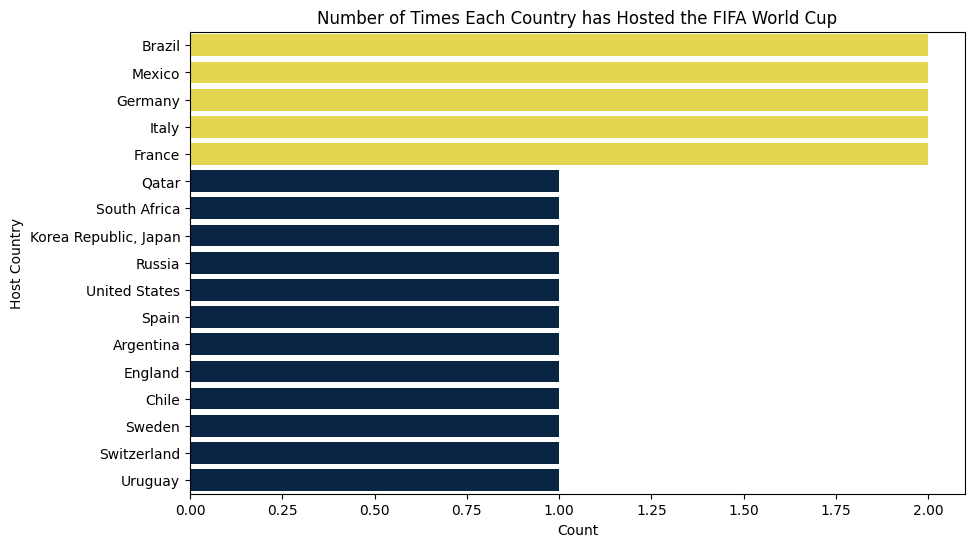

In [16]:
host_counts = champions['Host'].value_counts().reset_index()
host_counts.columns = ['Host', 'Count']

# Plotting the data using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Host', data=host_counts, palette='cividis',  hue='Count' , dodge=False , legend=False)
plt.title('Number of Times Each Country has Hosted the FIFA World Cup')
plt.xlabel('Count')
plt.ylabel('Host Country')

## Now let's deal with another data set

In [17]:
rank = pd.read_csv("fifa_ranking_2022-10-06.csv")
rank.head()

,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46


In [18]:
rank.drop('team_code', axis=1, inplace=True)

In [19]:
duplicate_rows = rank[rank.duplicated()]
len(duplicate_rows)

0

In [20]:
rank.isnull().sum()

team               0
association        0
rank               0
previous_rank      0
points             0
previous_points    0
dtype: int64

In [21]:
print(rank['team'].nunique())
print(rank['rank'].nunique())

211
211


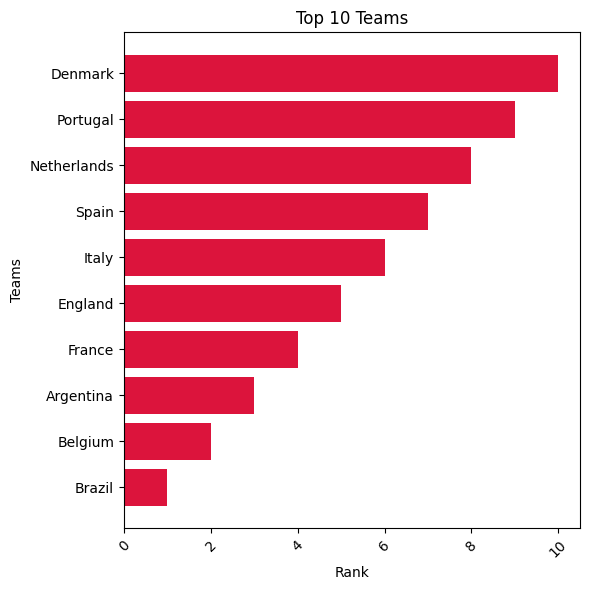

In [24]:
top_10 = rank.nsmallest(10, 'rank')

plt.figure(figsize=(6, 6))
plt.barh(top_10['team'], top_10['rank'], color='crimson')
plt.ylabel('Teams')
plt.xlabel('Rank')
plt.title('Top 10 Teams')
plt.xticks(rotation=45)
plt.tight_layout()

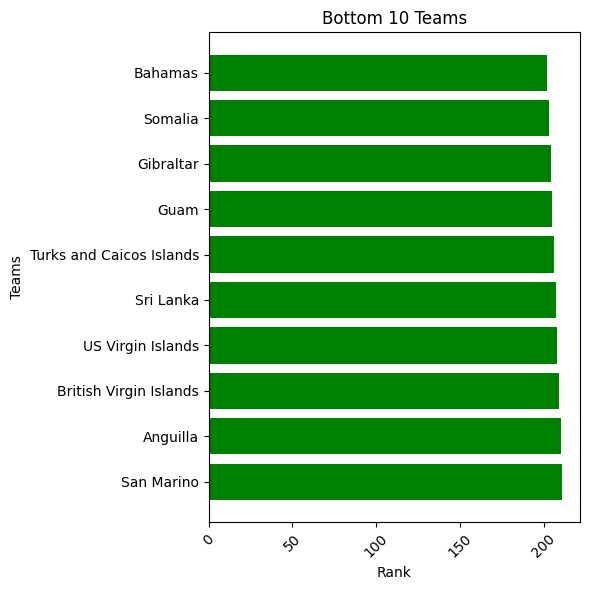

In [27]:
bottom_10 = rank.nlargest(10, 'rank')

plt.figure(figsize=(6, 6))
plt.barh(bottom_10['team'], bottom_10['rank'], color='green')
plt.ylabel('Teams')
plt.xlabel('Rank')
plt.title('Bottom 10 Teams')
plt.xticks(rotation=45)
plt.tight_layout()

In [28]:
fallen_team = rank[rank['rank'] > rank['previous_rank']]
fallen_team

,team,association,rank,previous_rank,points,previous_points
6,Spain,UEFA,7,6,1715.22,1716.93
12,Mexico,CONCACAF,13,12,1644.89,1649.57
13,Uruguay,CONMEBOL,14,13,1638.71,1640.95
15,USA,CONCACAF,16,14,1627.48,1635.01
22,Peru,CONMEBOL,23,21,1561.01,1562.24
...,...,...,...,...,...,...
178,Montserrat,CONCACAF,179,178,940.78,940.78
186,Laos,AFC,187,183,905.51,914.66
195,Liechtenstein,UEFA,196,194,862.39,873.99
198,Seychelles,CAF,199,198,859.56,860.48


In [29]:
up_team = rank[rank['rank'] < rank['previous_rank']]
up_team

,team,association,rank,previous_rank,points,previous_points
5,Italy,UEFA,6,7,1726.14,1713.86
11,Croatia,UEFA,12,15,1645.64,1632.15
14,Switzerland,UEFA,15,16,1635.92,1621.43
19,IR Iran,AFC,20,22,1564.61,1558.64
20,Serbia,UEFA,21,25,1563.62,1549.53
...,...,...,...,...,...,...
197,Timor-Leste,AFC,198,199,860.06,860.06
199,Eritrea,CAF,200,201,855.56,855.56
200,Aruba,CONCACAF,201,202,855.37,855.37
201,Bahamas,CONCACAF,202,203,854.80,854.80


In [30]:
teams_that_rank_does_not_cahnge = rank[rank['rank'] == rank['previous_rank']]
teams_that_rank_does_not_cahnge

,team,association,rank,previous_rank,points,previous_points
0,Brazil,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,UEFA,2,2,1816.71,1821.92
2,Argentina,CONMEBOL,3,3,1773.88,1770.65
3,France,UEFA,4,4,1759.78,1764.85
4,England,UEFA,5,5,1728.47,1737.46
...,...,...,...,...,...,...
206,Sri Lanka,AFC,207,207,825.25,825.25
207,US Virgin Islands,CONCACAF,208,208,823.97,823.97
208,British Virgin Islands,CONCACAF,209,209,809.32,809.32
209,Anguilla,CONCACAF,210,210,790.74,790.74


Text(0.5, 1.0, 'Team Rank Changes')

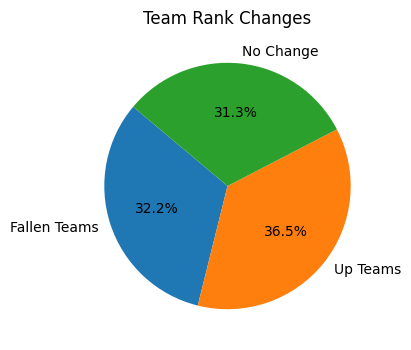

In [31]:
counts = [len(fallen_team), len(up_team), len(teams_that_rank_does_not_cahnge)]
labels = ['Fallen Teams', 'Up Teams', 'No Change']

# Plotting the pie chart
plt.figure(figsize=(6, 4))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Team Rank Changes')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'CONMEBOL'),
  Text(1, 0, 'UEFA'),
  Text(2, 0, 'CONCACAF'),
  Text(3, 0, 'CAF'),
  Text(4, 0, 'AFC'),
  Text(5, 0, 'OFC')])

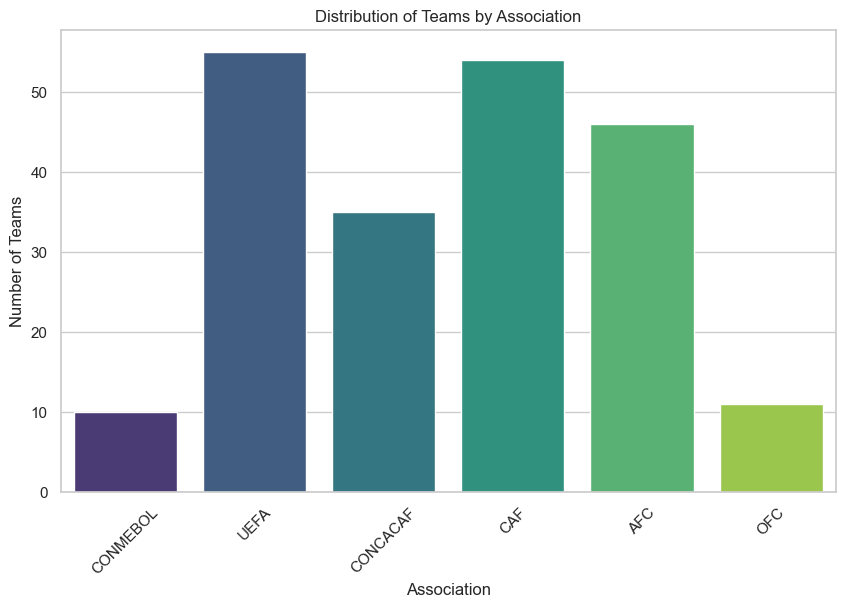

In [32]:
sns.set(style="whitegrid")

# Creating the bar plot using seaborn
plt.figure(figsize=(10, 6))
sns.countplot(data=rank, x='association', hue='association', palette='viridis', dodge=False, legend=False)

# Adding titles and labels
plt.title('Distribution of Teams by Association')
plt.xlabel('Association')
plt.ylabel('Number of Teams')
plt.xticks(rotation=45)

In [33]:
average_points = rank['points'].mean()
max_points = rank['points'].max()
min_points = rank['points'].min()

# Find team with maximum points
team_max_points = rank.loc[rank['points'].idxmax(), 'team']

# Find team with minimum points
team_min_points = rank.loc[rank['points'].idxmin(), 'team']

# Print statements with corrected team names
print("Maximum points:", max_points, team_max_points)
print("Minimum points:", min_points, team_min_points)
print("Average points:", average_points)

Maximum points: 1841.3 Brazil
Minimum points: 762.22 San Marino
Average points: 1220.687345971564


In [34]:
matches = pd.read_csv('matches_1930_2022.csv')
matches

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959,Argentina,France,1,NaN,NaN,0,NaN,NaN,Francisco Olazar,Manuel Ferreira,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960,Yugoslavia,Brazil,2,NaN,NaN,1,NaN,NaN,Bosko Simonovic,Milutin Ivković,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
961,Romania,Peru,3,NaN,NaN,1,NaN,NaN,Octav Luchide,Emerich Vogl,...,NaN,NaN,NaN,Plácido Galindo · 70,NaN,NaN,NaN,NaN,NaN,NaN
962,United States,Belgium,3,NaN,NaN,0,NaN,NaN,Bob Millar,Tom Florie,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
matches.columns

Index(['home_team', 'away_team', 'home_score', 'home_xg', 'home_penalty',
       'away_score', 'away_xg', 'away_penalty', 'home_manager', 'home_captain',
       'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials',
       'Round', 'Date', 'Score', 'Referee', 'Notes', 'Host', 'Year',
       'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long',
       'home_own_goal', 'away_own_goal', 'home_penalty_goal',
       'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long',
       'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long',
       'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long',
       'home_red_card', 'away_red_card', 'home_yellow_red_card',
       'away_yellow_red_card', 'home_yellow_card_long',
       'away_yellow_card_long', 'home_substitute_in_long',
       'away_substitute_in_long'],
      dtype='object')

In [36]:
len(matches)

964

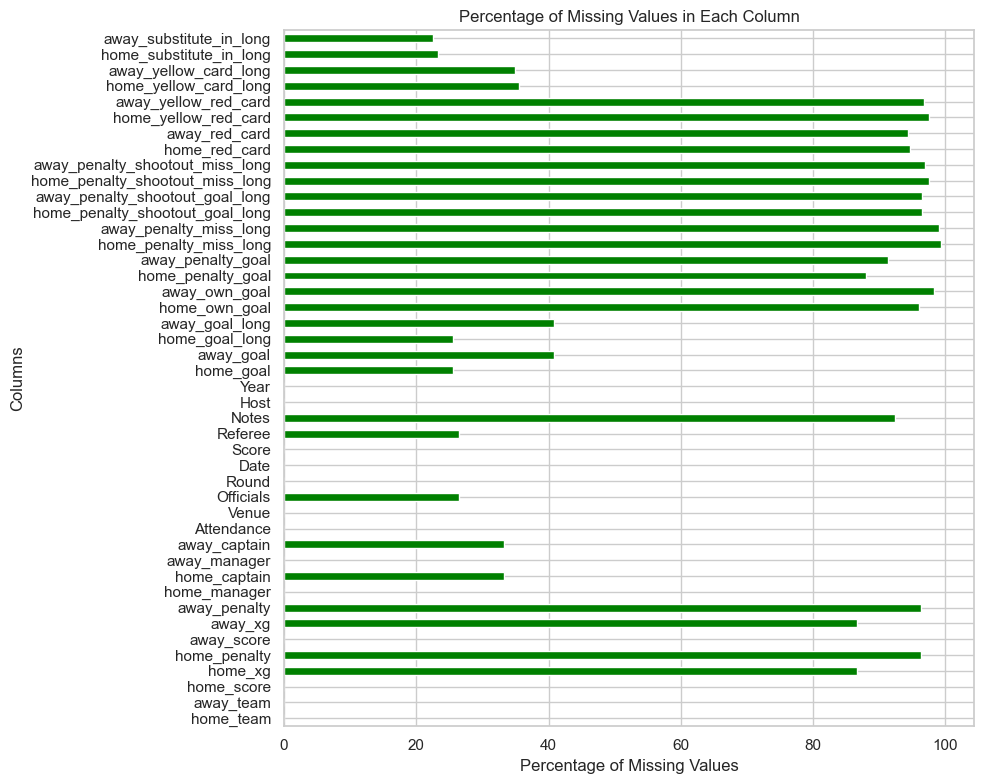

In [38]:
null_counts = (matches.isnull().sum() / len(matches) * 100)
plt.figure(figsize=(10, 8))
null_counts.plot(kind='barh', color='green')
plt.title('Percentage of Missing Values in Each Column')
plt.ylabel('Columns')
plt.xlabel('Percentage of Missing Values')
plt.tight_layout()

In [39]:
for column in matches.columns :
    
    null_counts = (matches[column].isnull().sum() / len(matches) * 100)
    
    if null_counts > 50 : 
        matches.drop(column, axis=1, inplace=True)

In [40]:
matches.columns

Index(['home_team', 'away_team', 'home_score', 'away_score', 'home_manager',
       'home_captain', 'away_manager', 'away_captain', 'Attendance', 'Venue',
       'Officials', 'Round', 'Date', 'Score', 'Referee', 'Host', 'Year',
       'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long',
       'home_yellow_card_long', 'away_yellow_card_long',
       'home_substitute_in_long', 'away_substitute_in_long'],
      dtype='object')

In [41]:
duplicate_rows = matches[matches.duplicated()]
len(duplicate_rows)

0

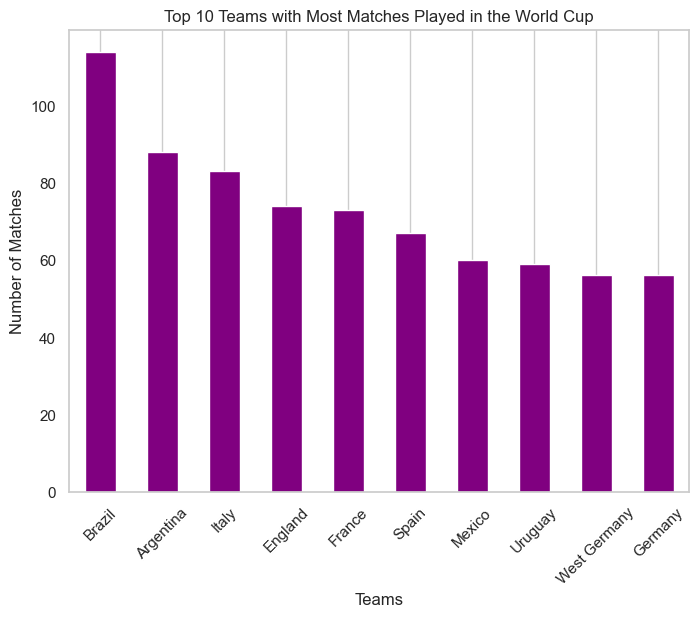

In [43]:
# Count the matches played by each team
home_counts = matches['home_team'].value_counts()
away_counts = matches['away_team'].value_counts()

# Sum the counts
total_counts = home_counts.add(away_counts, fill_value=0)

# Sort and select the top 10 teams
top_10_teams = total_counts.sort_values(ascending=False).head(10)

# Plotting the top 10 teams
plt.figure(figsize=(8, 6))
top_10_teams.plot(kind='bar', color='purple')
plt.title('Top 10 Teams with Most Matches Played in the World Cup')
plt.xlabel('Teams')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.grid(axis='y')

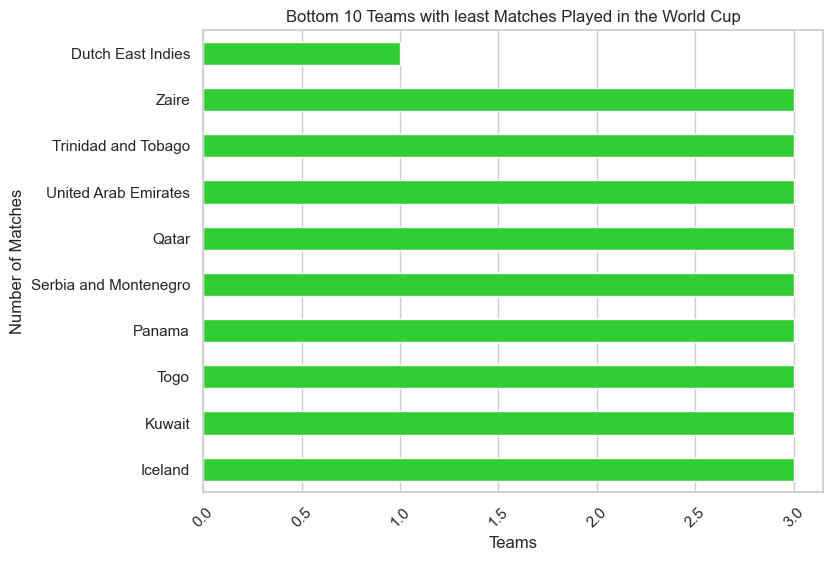

In [45]:
bottom_10_teams = total_counts.sort_values(ascending=False).tail(10)

# Plotting the top 10 teams
plt.figure(figsize=(8, 6))
bottom_10_teams.plot(kind='barh', color='limegreen')
plt.title('Bottom 10 Teams with least Matches Played in the World Cup')
plt.xlabel('Teams')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.grid(axis='y')

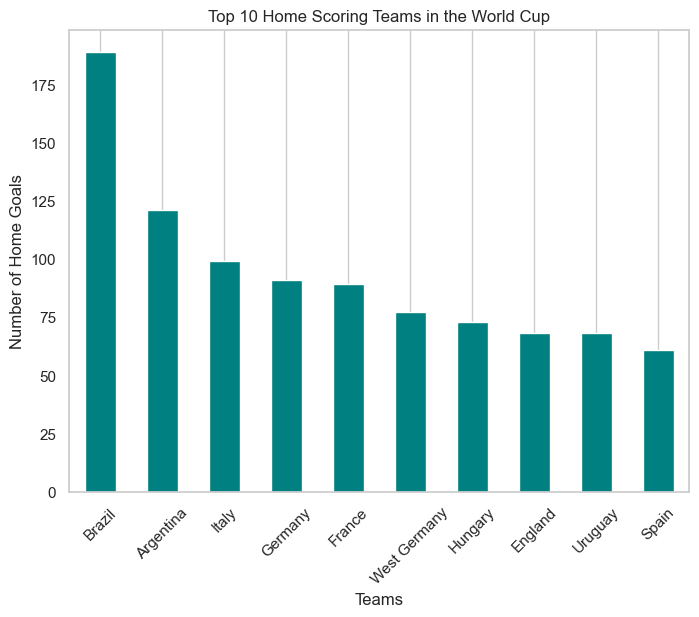

In [46]:
home_goals = matches.groupby('home_team')['home_score'].sum()

# Sort and select the top 10 home scoring teams
top_10_home_scoring_teams = home_goals.sort_values(ascending=False).head(10)

# Plotting the top 10 home scoring teams
plt.figure(figsize=(8, 6))
top_10_home_scoring_teams.plot(kind='bar', color='teal')
plt.title('Top 10 Home Scoring Teams in the World Cup')
plt.xlabel('Teams')
plt.ylabel('Number of Home Goals')
plt.xticks(rotation=45)
plt.grid(axis='y')

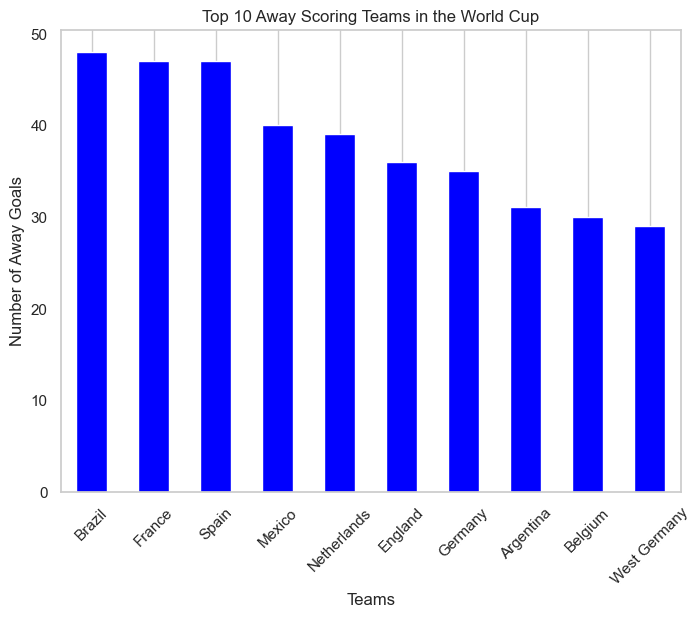

In [48]:
away_goals = matches.groupby('away_team')['away_score'].sum()

# Sort and select the top 10 home scoring teams
top_10_away_scoring_teams = away_goals.sort_values(ascending=False).head(10)

# Plotting the top 10 home scoring teams
plt.figure(figsize=(8, 6))
top_10_away_scoring_teams.plot(kind='bar', color='blue')
plt.title('Top 10 Away Scoring Teams in the World Cup')
plt.xlabel('Teams')
plt.ylabel('Number of Away Goals')
plt.xticks(rotation=45)
plt.grid(axis='y')

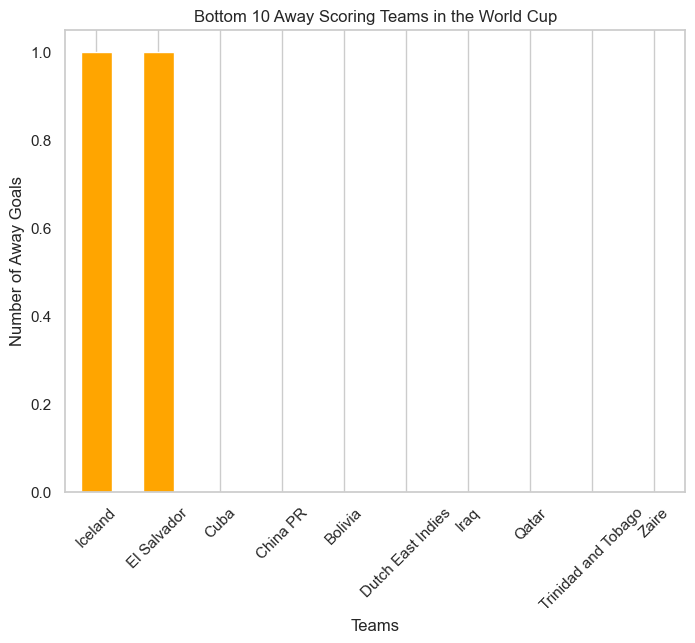

In [49]:
bottom_10_away_scoring_teams = away_goals.sort_values(ascending=False).tail(10)

# Plotting the top 10 home scoring teams
plt.figure(figsize=(8, 6))
bottom_10_away_scoring_teams.plot(kind='bar', color='orange')
plt.title('Bottom 10 Away Scoring Teams in the World Cup')
plt.xlabel('Teams')
plt.ylabel('Number of Away Goals')
plt.xticks(rotation=45)
plt.grid(axis='y'   )

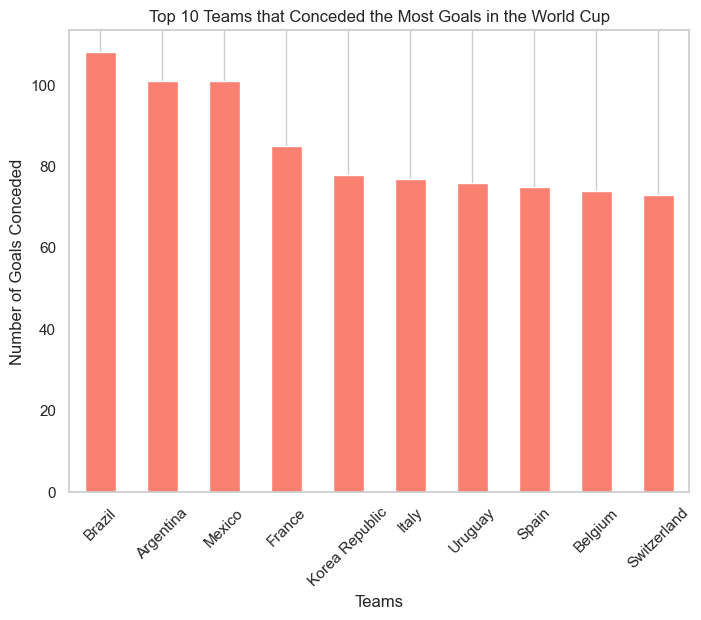

In [50]:
goals_conceded_home = matches.groupby('home_team')['away_score'].sum()
goals_conceded_away = matches.groupby('away_team')['home_score'].sum()

# Combine the two Series
total_goals_conceded = goals_conceded_home.add(goals_conceded_away, fill_value=0)

# Sort and select the top 10 teams that conceded the most goals
top_10_conceding_teams = total_goals_conceded.sort_values(ascending=False).head(10)

# Plotting the top 10 conceding teams
plt.figure(figsize=(8, 6))
top_10_conceding_teams.plot(kind='bar', color='salmon')
plt.title('Top 10 Teams that Conceded the Most Goals in the World Cup')
plt.xlabel('Teams')
plt.ylabel('Number of Goals Conceded')
plt.xticks(rotation=45)
plt.grid(axis='y')

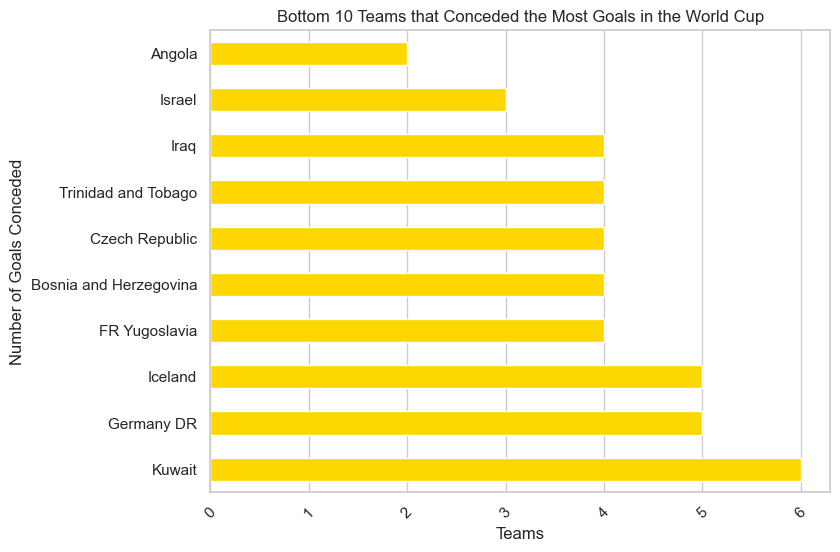

In [51]:
bottom_10_conceding_teams = total_goals_conceded.sort_values(ascending=False).tail(10)

# Plotting the top 10 conceding teams
plt.figure(figsize=(8, 6))
bottom_10_conceding_teams.plot(kind='barh', color='gold')
plt.title('Bottom 10 Teams that Conceded the Most Goals in the World Cup')
plt.xlabel('Teams')
plt.ylabel('Number of Goals Conceded')
plt.xticks(rotation=45)
plt.grid(axis='y')
